In [ ]:
import pandas as pd
import numpy as np

print("--- Task 2: Store A/B Testing Preparation ---\n")

# 1. Load the cleaned dataset from Task 1
try:
    data = pd.read_csv('QVI_Cleaned_Master_Data.csv')
    print("✅ Cleaned dataset loaded successfully.")
except FileNotFoundError:
    print("❌ ERROR: Please upload 'QVI_Cleaned_Master_Data.csv' to Colab first!")

# 2. Extract Year-Month for monthly aggregation
# Convert the date string to a datetime object, then format it as an integer (YYYYMM)
data['DATE'] = pd.to_datetime(data['DATE'])
data['YEARMONTH'] = data['DATE'].dt.strftime('%Y%m').astype(int)

# 3. Define the Metrics and Aggregate
# We group the data by Store and Month, then calculate our target metrics
print("Aggregating metrics per store, per month...")
store_metrics = data.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    TOT_SALES=('TOT_SALES', 'sum'),
    N_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
    N_TXN=('TXN_ID', 'nunique') # Count unique transactions
).reset_index()

# 4. Calculate Transactions per Customer
store_metrics['TXN_PER_CUST'] = store_metrics['N_TXN'] / store_metrics['N_CUSTOMERS']

print("\n🎉 SUCCESS: Data successfully aggregated!")
print(f"Total store-month records generated: {len(store_metrics)}")
print("Preview of the aggregated store metrics:")
display(store_metrics.head())

--- Task 2: Store A/B Testing Preparation ---

✅ Cleaned dataset loaded successfully.
Aggregating metrics per store, per month...

🎉 SUCCESS: Data successfully aggregated!
Total store-month records generated: 3165
Preview of the aggregated store metrics:


,STORE_NBR,YEARMONTH,TOT_SALES,N_CUSTOMERS,N_TXN,TXN_PER_CUST
0,1,201807,188.9,47,49,1.042553
1,1,201808,168.4,41,41,1.000000
2,1,201809,268.1,57,59,1.035088
3,1,201810,175.4,39,40,1.025641
4,1,201811,184.8,44,45,1.022727


In [ ]:
print("--- Step 3: Finding the Control Stores ---\n")

# 1. Filter for the pre-trial period ONLY (Prior to Feb 2019)
pre_trial_data = store_metrics[store_metrics['YEARMONTH'] < 201902]

# 2. Define the algorithm to find the twin store
def find_control_store(trial_store, metric):
    """
    Calculates the Pearson correlation for a given metric between the trial store
    and all other stores during the pre-trial period.
    """
    # Get the monthly trend for the trial store
    trial_trend = pre_trial_data[pre_trial_data['STORE_NBR'] == trial_store].set_index('YEARMONTH')[metric]

    correlations = []

    # Loop through all available stores
    all_stores = pre_trial_data['STORE_NBR'].unique()
    for control_store in all_stores:
        # Don't compare the trial store to itself!
        if control_store == trial_store:
            continue

        # Get the monthly trend for the candidate control store
        control_trend = pre_trial_data[pre_trial_data['STORE_NBR'] == control_store].set_index('YEARMONTH')[metric]

        # Only compare if both stores have a full 7 months of pre-trial data
        if len(control_trend) == 7 and len(trial_trend) == 7:
            # Calculate how closely their trends match (Pearson Correlation)
            corr_score = trial_trend.corr(control_trend)
            correlations.append({'Control_Store': control_store, 'Correlation': corr_score})

    # Convert results to a DataFrame and sort to find the highest match
    corr_df = pd.DataFrame(correlations)
    best_match = corr_df.sort_values(by='Correlation', ascending=False).iloc[0]

    return int(best_match['Control_Store']), best_match['Correlation']

# 3. Execute the algorithm for our three trial stores based on Total Sales
trial_stores = [77, 86, 88]
control_assignments = {}

print("Executing matching algorithm...\n")
for trial in trial_stores:
    # We will find the best match based on Total Sales
    best_control, score = find_control_store(trial, 'TOT_SALES')
    control_assignments[trial] = best_control

    print(f"✅ Trial Store {trial} -> Best Twin: Control Store {best_control} (Correlation Score: {score:.3f})")

--- Step 3: Finding the Control Stores ---

Executing matching algorithm...

✅ Trial Store 77 -> Best Twin: Control Store 233 (Correlation Score: 0.974)
✅ Trial Store 86 -> Best Twin: Control Store 155 (Correlation Score: 0.870)
✅ Trial Store 88 -> Best Twin: Control Store 159 (Correlation Score: 0.939)


--- Step 4: Visualizing Trial Performance ---



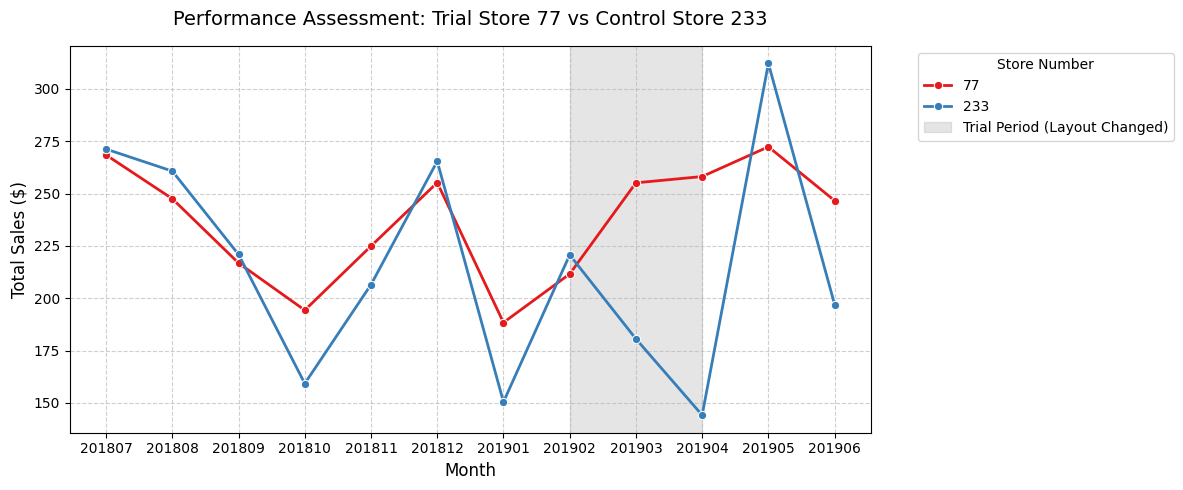

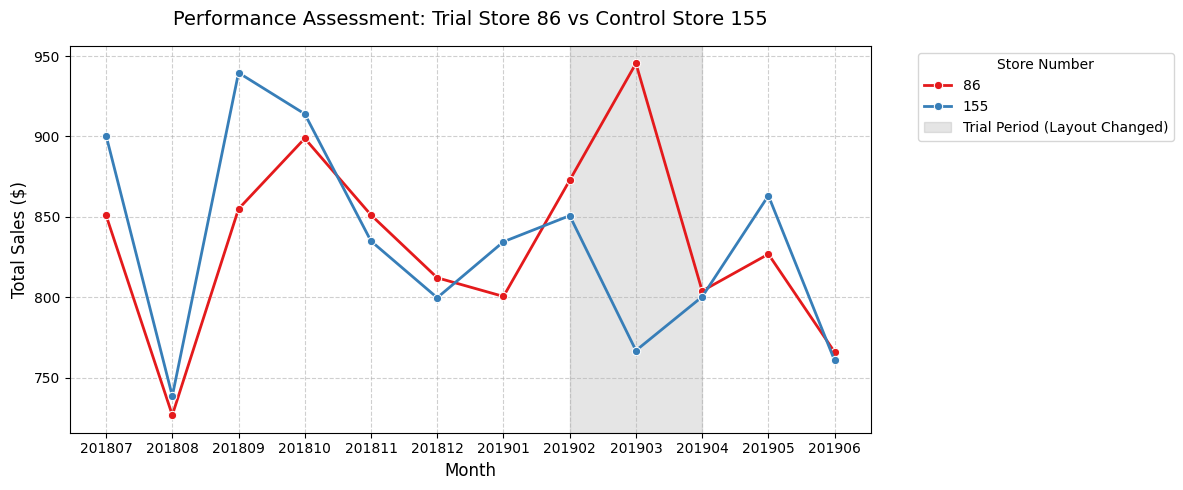

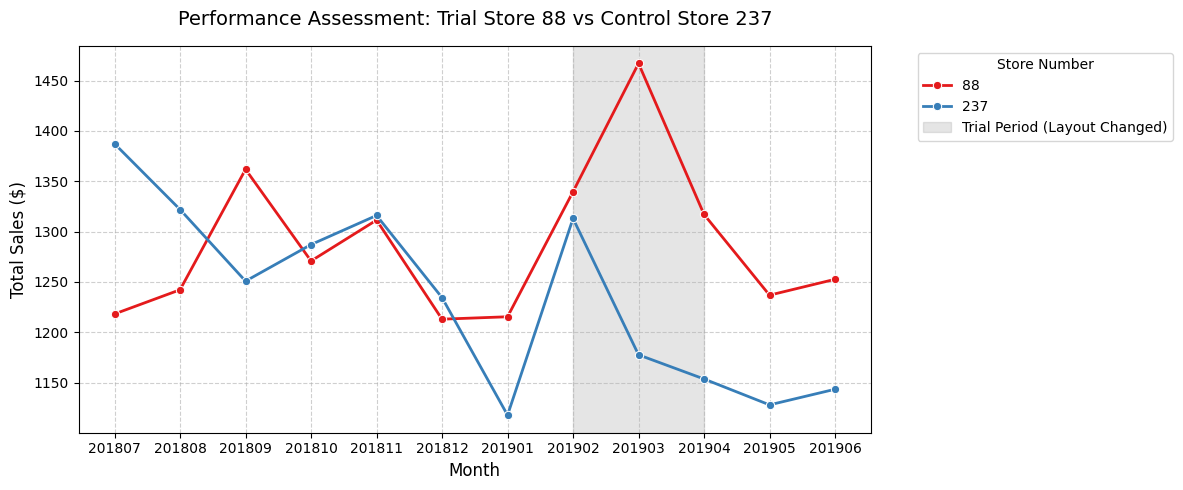

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Step 4: Visualizing Trial Performance ---\n")

# We will create a function to easily plot any pair of stores
def plot_trial_assessment(trial_store, control_store, metric='TOT_SALES'):
    # Extract data for just these two stores
    pair_data = store_metrics[store_metrics['STORE_NBR'].isin([trial_store, control_store])]

    # Convert YEARMONTH back to a string so it plots nicely on the axis
    pair_data = pair_data.copy()
    pair_data['YEARMONTH_STR'] = pair_data['YEARMONTH'].astype(str)

    # Set up the chart
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=pair_data, x='YEARMONTH_STR', y=metric, hue='STORE_NBR',
                 palette='Set1', marker='o', linewidth=2)

    # Highlight the Trial Period (Feb 2019 to April 2019)
    plt.axvspan('201902', '201904', alpha=0.2, color='grey', label='Trial Period (Layout Changed)')

    plt.title(f'Performance Assessment: Trial Store {trial_store} vs Control Store {control_store}', fontsize=14, pad=15)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Total Sales ($)', fontsize=12)
    plt.legend(title='Store Number', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Run the visualizer for all three of our matched pairs!
plot_trial_assessment(77, 233)
plot_trial_assessment(86, 155)
plot_trial_assessment(88, 237)